<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-02-20 19:16:42--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  41.1MB/s    in 4.9s    

2026-02-20 19:16:47 (41.3 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 125.1 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 109.6 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


       CompTotal
0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
...          ...
65432        NaN
65433        NaN
65434        NaN
65435        NaN
65436        NaN

[65437 rows x 1 columns]


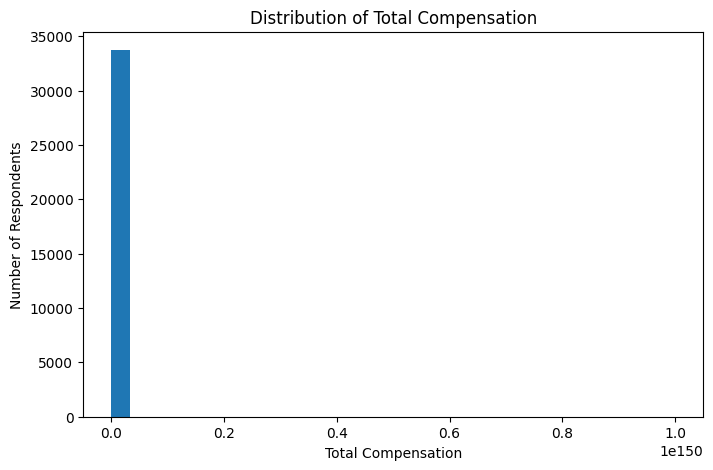

In [9]:
## Write your code here
QUERY = "SELECT CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)
#df['CompTotal'].value_counts()
plt.figure(figsize=(8,5))
plt.hist(df['CompTotal'].dropna(), bins=30)

plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Total Compensation")

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


      YearsCodePro
0              NaN
1               17
2               27
3              NaN
4              NaN
...            ...
65432            3
65433          NaN
65434            5
65435            2
65436          NaN

[65437 rows x 1 columns]


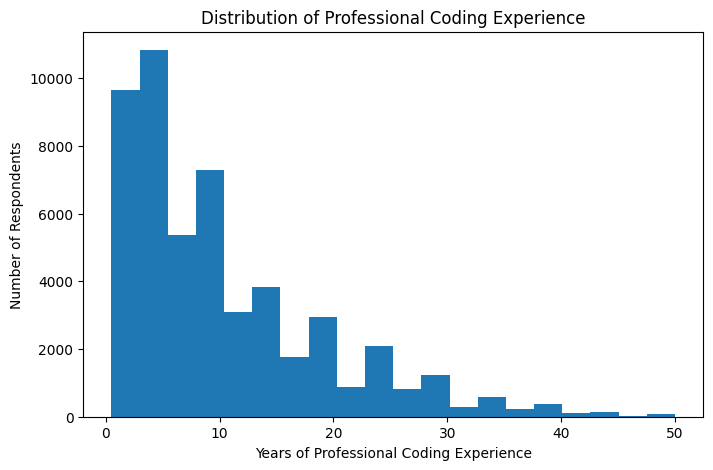

In [13]:
## Write your code here
QUERY = "SELECT YearsCodePro FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)
df['YearsCodePro_clean'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 50
})

df['YearsCodePro_clean'] = pd.to_numeric(df['YearsCodePro_clean'], errors='coerce')
plt.figure(figsize=(8,5))

plt.hist(df['YearsCodePro_clean'].dropna(), bins=20)

plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Professional Coding Experience")

plt.show()


### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


Upper limit: 535000.0
Lower limit: -225000.0


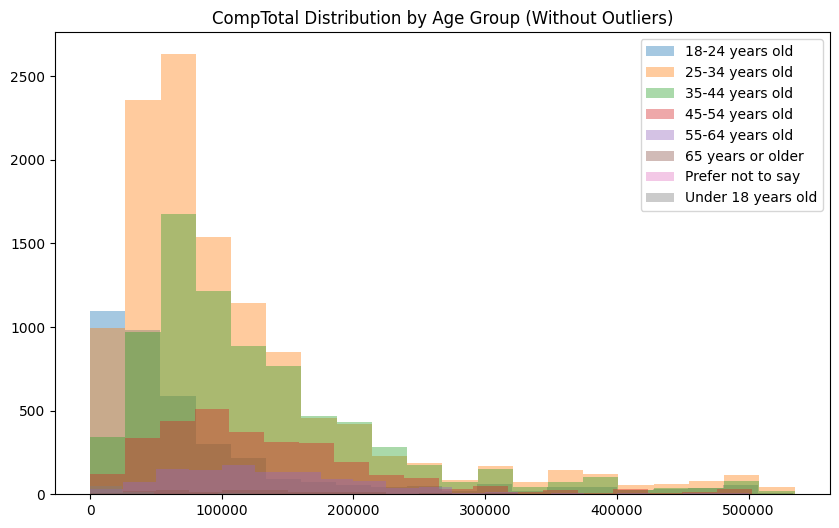

In [14]:
## Write your code here
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print("Upper limit:", upper_limit)
print("Lower limit:", lower_limit)
df_no_outliers = df[
    (df['CompTotal'] >= lower_limit) &
    (df['CompTotal'] <= upper_limit)
]

plt.figure(figsize=(10,6))

for age, group in df_no_outliers.groupby('Age'):
    plt.hist(group['CompTotal'], bins=20, alpha=0.4, label=age)

plt.legend()
plt.title("CompTotal Distribution by Age Group (Without Outliers)")
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


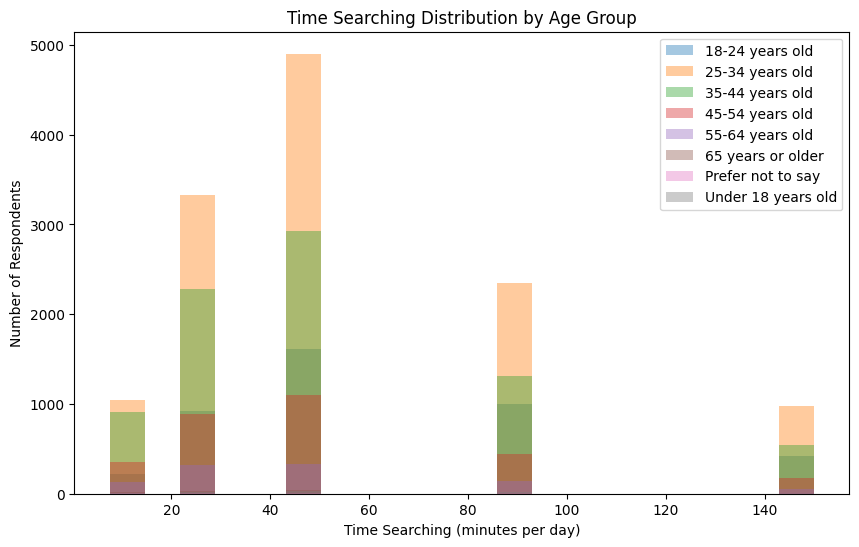

In [23]:
## Write your code here
QUERY = """
SELECT Age, TimeSearching
FROM main
WHERE TimeSearching IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
df['TimeSearching'].value_counts()
df['TimeSearching_numeric'] = df['TimeSearching'].replace({
    'Less than 15 minutes a day': 7.5,     
    '15-30 minutes a day': 22.5,            
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150           
})
plt.figure(figsize=(10,6))

for age, group in df.groupby('Age'):
    plt.hist(group['TimeSearching_numeric'], bins=20, alpha=0.4, label=age)

plt.xlabel("Time Searching (minutes per day)")
plt.ylabel("Number of Respondents")
plt.title("Time Searching Distribution by Age Group")
plt.legend()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


  DatabaseWantToWorkWith  count
0                    NaN  22879
1             PostgreSQL   3738
2      PostgreSQL;SQLite   1533
3                 SQLite   1476
4   Microsoft SQL Server   1431


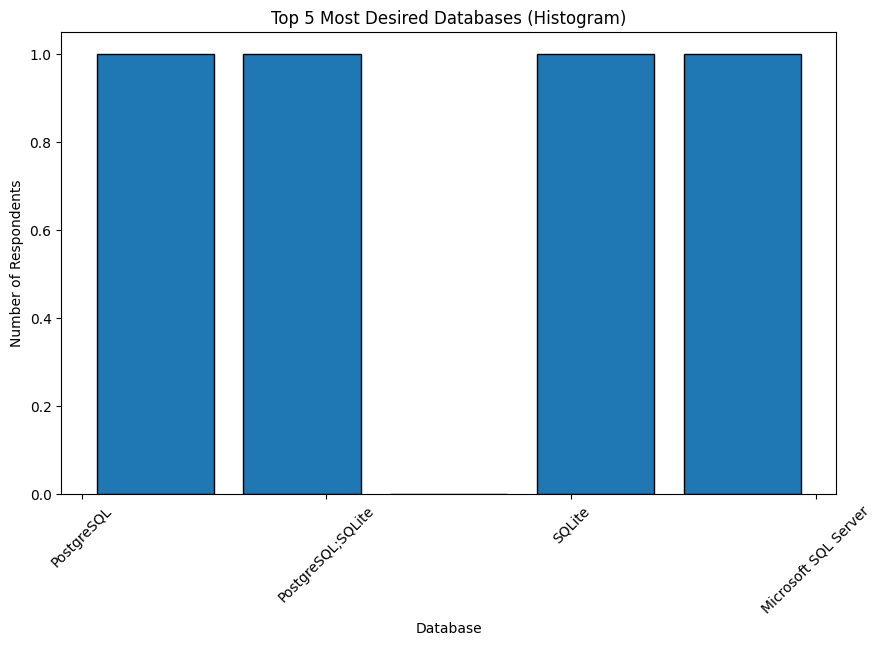

In [35]:
## Write your code here
QUERY = """
SELECT DatabaseWantToWorkWith, COUNT(*) as count
FROM main
GROUP BY DatabaseWantToWorkWith
ORDER BY count DESC
LIMIT 5
"""
df_DatabaseWantToWorkWith = pd.read_sql_query(QUERY, conn)
print(df_DatabaseWantToWorkWith)
df_top5 = df_DatabaseWantToWorkWith[df_DatabaseWantToWorkWith['DatabaseWantToWorkWith'].notna()]

df_top5 = df_top5.head(5)

db_mapping = {db: i+1 for i, db in enumerate(df_top5['DatabaseWantToWorkWith'])}
df_top5['Database_numeric'] = df_top5['DatabaseWantToWorkWith'].map(db_mapping)


plt.figure(figsize=(10,6))
plt.hist(df_top5['Database_numeric'], bins=5, edgecolor='black', rwidth=0.8)

plt.xticks(ticks=list(db_mapping.values()), labels=list(db_mapping.keys()), rotation=45)

plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.title("Top 5 Most Desired Databases (Histogram)")

# 7️⃣ عرض الرسم
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


  RemoteWork
0     Remote
1     Remote
2     Remote
3        NaN
4        NaN


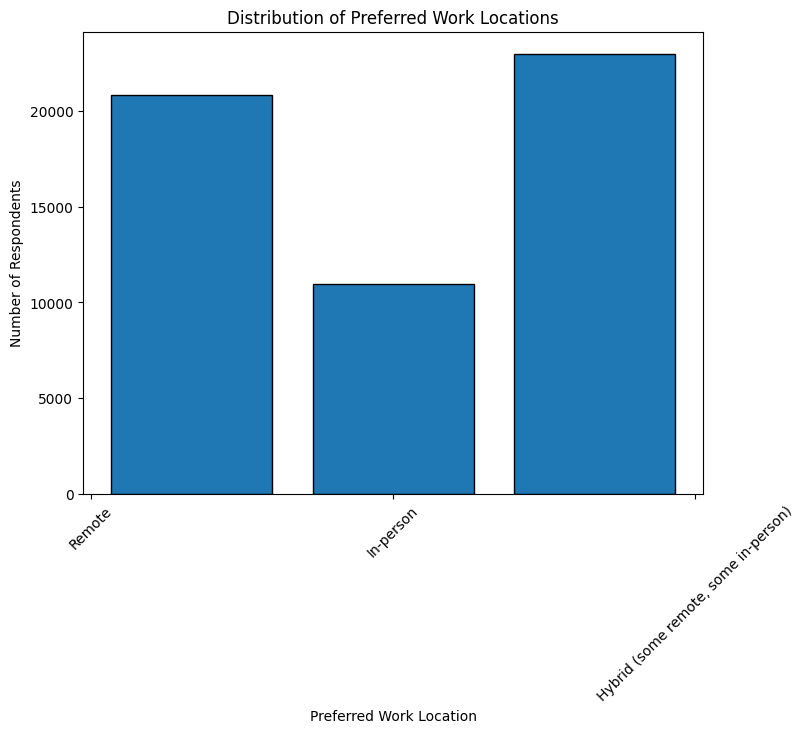

In [36]:
## Write your code here
QUERY = """
SELECT RemoteWork
FROM main
"""
df_remote = pd.read_sql_query(QUERY, conn)
print(df_remote.head())
df_remote = df_remote[df_remote['RemoteWork'].notna()]
df_remote = df_remote[df_remote['RemoteWork'] != 'Prefer not to say']
remote_mapping = {label: i+1 for i, label in enumerate(df_remote['RemoteWork'].unique())}
df_remote['Remote_numeric'] = df_remote['RemoteWork'].map(remote_mapping)
plt.figure(figsize=(8,6))
plt.hist(df_remote['Remote_numeric'], bins=len(remote_mapping), edgecolor='black', rwidth=0.8)

plt.xticks(ticks=list(remote_mapping.values()), labels=list(remote_mapping.keys()), rotation=45)

plt.xlabel("Preferred Work Location")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Preferred Work Locations")
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


               Age  CompTotal
0  45-54 years old        NaN
1  45-54 years old        NaN
2  45-54 years old        NaN
3  45-54 years old        NaN
4  45-54 years old        NaN


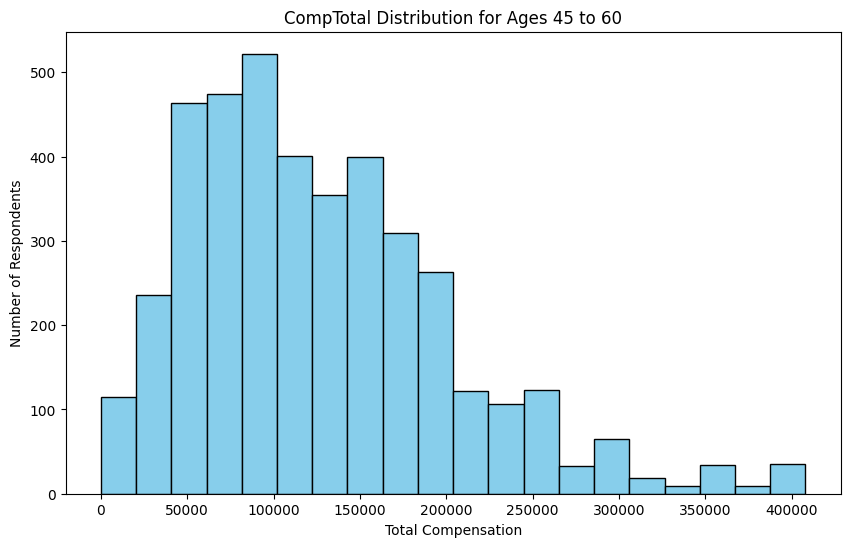

In [37]:
## Write your code here
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age BETWEEN '45-54 years old' AND '55-64 years old'
"""
df_age_45_60 = pd.read_sql_query(QUERY, conn)
print(df_age_45_60.head())
df_age_45_60['CompTotal_numeric'] = pd.to_numeric(df_age_45_60['CompTotal'], errors='coerce')

df_age_45_60 = df_age_45_60.dropna(subset=['CompTotal_numeric'])
Q1 = df_age_45_60['CompTotal_numeric'].quantile(0.25)
Q3 = df_age_45_60['CompTotal_numeric'].quantile(0.75)
IQR = Q3 - Q1
df_age_45_60 = df_age_45_60[(df_age_45_60['CompTotal_numeric'] >= Q1 - 1.5*IQR) &
                            (df_age_45_60['CompTotal_numeric'] <= Q3 + 1.5*IQR)]
plt.figure(figsize=(10,6))
plt.hist(df_age_45_60['CompTotal_numeric'], bins=20, edgecolor='black', color='skyblue')
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")
plt.title("CompTotal Distribution for Ages 45 to 60")
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


  YearsCodePro  JobSat
0          NaN     NaN
1           17     NaN
2           27     NaN
3          NaN     NaN
4          NaN     NaN


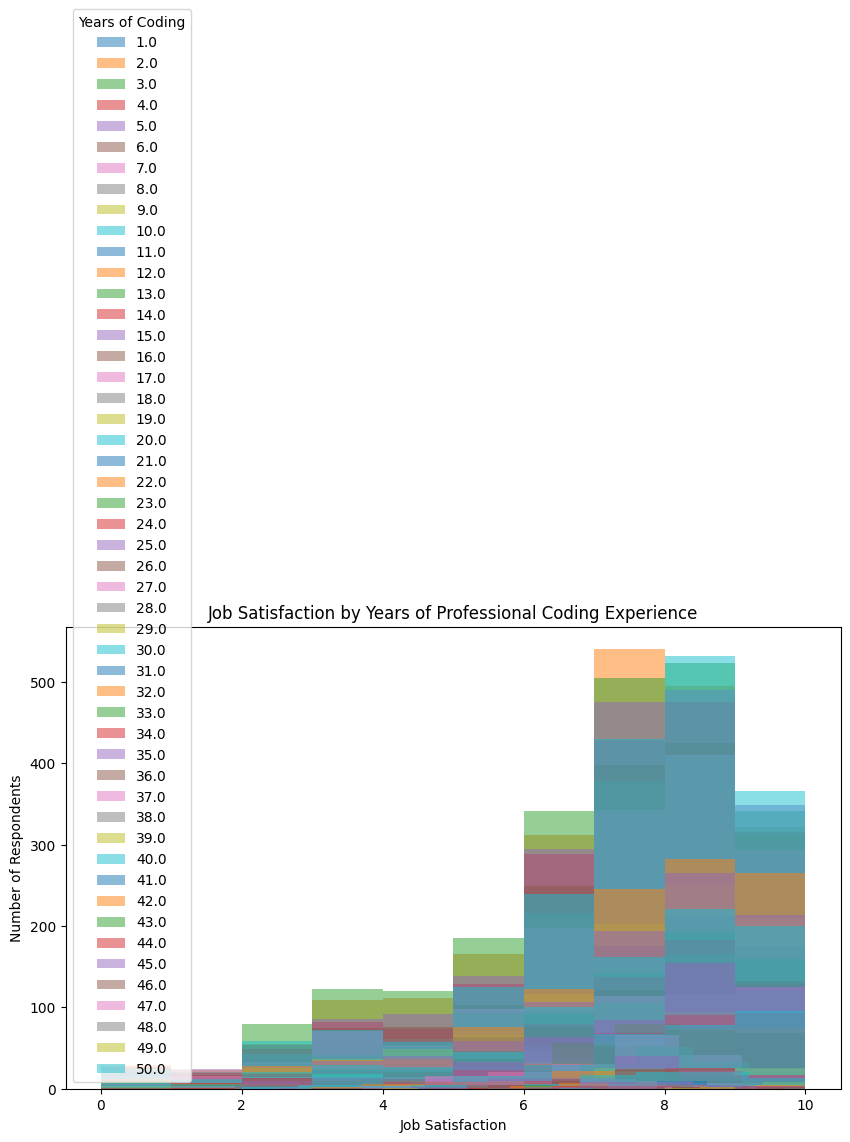

In [38]:
## Write your code here
QUERY = """
SELECT YearsCodePro, JobSat
FROM main
"""
df_job = pd.read_sql_query(QUERY, conn)
print(df_job.head())
df_job['YearsCodePro_numeric'] = pd.to_numeric(df_job['YearsCodePro'], errors='coerce')

df_job['JobSat_numeric'] = pd.to_numeric(df_job['JobSat'], errors='coerce')

df_job = df_job.dropna(subset=['YearsCodePro_numeric', 'JobSat_numeric'])
plt.figure(figsize=(10,6))
for years, group in df_job.groupby('YearsCodePro_numeric'):
    plt.hist(group['JobSat_numeric'], bins=10, alpha=0.5, label=str(years))

plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Respondents")
plt.title("Job Satisfaction by Years of Professional Coding Experience")
plt.legend(title="Years of Coding")
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
